## Часть 2. Работа с MLPClassifier

### <font color='#F5DEB3'> Подготовка обработанного датасета

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yaml

In [2]:
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [3]:
processed_path = os.path.join(config['data']['dataset_processed'], 'Data_Set_AB_processed.xlsx')

V13 = pd.read_excel(processed_path)

In [4]:
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

### <font color='#F5DEB3'>Задание №1

1. Для выполнения практикума рекомендуется использовать полносвязную нейронную сеть прямого распространения – **MLPClassifier** из библиотеки машинного обучения sklearn.
2. Провести небольшую предварительную серию экспериментов с параметрами *“hidden_layer_sizes”*, *“activation”*, *“solver”* и *“max_iter”*, добиваясь наиболее близких между собой значений **критерия кросс-валидации** (перекрестного критерия ошибки) на обучающей выборке (Data Set_Train).
3. **Необходимо добиться** в режиме работы «на результат» как можно более высокой точности прогнозирования выходной величины в зависимости от гиперпараметров.

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

import ast

In [15]:
def train_models(
    data_x, data_y,
    hidden_options,
    activation_options,
    solver_options,
    max_iter_options,
    random_state,
    cv_folds
):
    results = []
    combo_id = 0

    for hls in hidden_options:
        for act in activation_options:
            for solv in solver_options:
                for max_it in max_iter_options:
                    combo_id += 1
                    mlp = MLPClassifier(
                        hidden_layer_sizes=hls,
                        activation=act,
                        solver=solv,
                        max_iter=max_it,
                        random_state=random_state,
                    )

                    # Accuracy
                    scores_acc = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='accuracy')
                    mean_acc = scores_acc.mean()
                    std_acc = scores_acc.std()

                    # F1-score
                    scores_f1 = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='f1')
                    mean_f1 = scores_f1.mean()
                    std_f1 = scores_f1.std()

                    # Вывод в консоль
                    print(f"Номер набора № {combo_id}. Гиперпараметры: "
                          f"hidden_layer_sizes={hls}, activation={act}, solver={solv}, max_iter={max_it} → "
                          f"Accuracy: {mean_acc:.3f} (±{std_acc:.3f}), "
                          f"F1-score: {mean_f1:.3f} (±{std_f1:.3f})")

                    results.append({
                        'combo_id': combo_id,
                        'hidden_layer_sizes': str(hls),
                        'activation': act,
                        'solver': solv,
                        'max_iter': max_it,
                        'cv_mean_accuracy': mean_acc,
                        'cv_std_accuracy': std_acc,
                        'cv_mean_f1': mean_f1,
                        'cv_std_f1': std_f1
                    })

    df_results = pd.DataFrame(results)
    return df_results


def plot_results(
        df_results, 
        output_path=None, 
        figsize=(14, 7), 
        dpi=600):
    
    # Сортируем по убыванию F1
    df_sorted = df_results.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

    x = np.arange(len(df_sorted))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # Столбцы Accuracy
    bars_acc = ax.bar(
        x - width/2, df_sorted['cv_mean_accuracy'], width,
        yerr=df_sorted['cv_std_accuracy'], capsize=4,
        label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8
    )

    # Столбцы F1-score
    bars_f1 = ax.bar(
        x + width/2, df_sorted['cv_mean_f1'], width,
        yerr=df_sorted['cv_std_f1'], capsize=4,
        label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8
    )

    ax.set_xlabel('Номер комбинации')
    ax.set_ylabel('Значение метрики (0–1)')
    ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n(сортировка по убыванию F1)')
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['combo_id'])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Подписи значений на столбцах (опционально)
    for bar in bars_acc:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars_f1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi)

    plt.show()

def print_sorted_by_f1(df_results):
    # Сортируем по F1
    df_sorted = df_results.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)
    
    # Выбираем основные колонки для вывода
    cols_to_show = [
        'combo_id', 'hidden_layer_sizes', 'activation', 'solver', 'max_iter',
        'cv_mean_f1', 'cv_std_f1', 'cv_mean_accuracy', 'cv_std_accuracy'
    ]
    
    # Настройки отображения pandas (показываем все строки, не обрезаем)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        print("\n=== Результаты гиперпараметрического поиска (сортировка по убыванию F1) ===\n")
        print(df_sorted[cols_to_show].to_string(index=False))


def plot_model_by_combo_id(combo_id, df_results, data_x, data_y, random_state, n_show=None):
    # 1. Поиск комбинации в таблице результатов
    selected_row = df_results[df_results['combo_id'] == combo_id]
    if selected_row.empty:
        print(f"Ошибка: комбинация с номером {combo_id} не найдена!")
        return
    row = selected_row.iloc[0]

    # 2. Извлечение гиперпараметров
    hls = ast.literal_eval(row['hidden_layer_sizes'])
    act = row['activation']
    solv = row['solver']
    max_it = row['max_iter']

    # 3. Вывод информации о модели (в требуемом формате)
    print(f"Номер выборки - {combo_id}")
    print(f"Гиперпараметры - hidden_layer_sizes={hls}, activation='{act}', solver='{solv}', max_iter={max_it}")
    print(f"Accuracy = {row['cv_mean_accuracy']:.4f} ± {row['cv_std_accuracy']:.4f}, "
          f"F1-score = {row['cv_mean_f1']:.4f} ± {row['cv_std_f1']:.4f}")

    # 4. Создание и обучение модели на ВСЕХ данных (не только на кросс-валидации)
    mlp = MLPClassifier(
        hidden_layer_sizes=hls,
        activation=act,
        solver=solv,
        max_iter=max_it,
        random_state=random_state,
    )
    mlp.fit(data_x, data_y)

    # 5. Предсказание классов
    y_pred_class = mlp.predict(data_x)

    # 6. Визуализация
    if n_show is None:
        n_show = min(1000, len(data_y))
    indices = np.arange(n_show)

    plt.figure(figsize=(14, 6))
    plt.plot(indices, data_y[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred_class[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0 или 1)')
    plt.title(f'Сравнение реальных и предсказанных классов (комбинация №{combo_id}, первые {n_show} примеров)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'model_combo_{combo_id}.png', dpi=600)
    plt.show()

#### <font color='#F5DEB3'> 1.1 Тестирование с одним слоем

In [7]:
hidden_opts = [(10), (100), (1000)]
act_opts = ['relu', 'tanh', 'logistic']
solv_opts = ['adam', 'lbfgs', 'sgd']
iter_opts = [1000, 5000]

In [8]:
df_res = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 1. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.756 (±0.030)F1-score: 0.139 (±0.155)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.756 (±0.030)F1-score: 0.139 (±0.155)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.705 (±0.053)F1-score: 0.188 (±0.189)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.705 (±0.053)F1-score: 0.188 (±0.189)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=sgd, max_iter=1000 → Accuracy: 0.773 (±0.048)F1-score: 0.100 (±0.100)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=10, activation=relu, solver=sgd, max_iter=5000 → Accuracy: 0.773 (±0.048)F1-score: 0.100 (±0.100)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=10, activation=tanh, solver=adam, m

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 15. Гиперпараметры: hidden_layer_sizes=10, activation=logistic, solver=lbfgs, max_iter=1000 → Accuracy: 0.688 (±0.034)F1-score: 0.033 (±0.058)
Номер набора № 16. Гиперпараметры: hidden_layer_sizes=10, activation=logistic, solver=lbfgs, max_iter=5000 → Accuracy: 0.693 (±0.041)F1-score: 0.033 (±0.058)
Номер набора № 17. Гиперпараметры: hidden_layer_sizes=10, activation=logistic, solver=sgd, max_iter=1000 → Accuracy: 0.795 (±0.000)F1-score: 0.000 (±0.000)
Номер набора № 18. Гиперпараметры: hidden_layer_sizes=10, activation=logistic, solver=sgd, max_iter=5000 → Accuracy: 0.795 (±0.000)F1-score: 0.000 (±0.000)
Номер набора № 19. Гиперпараметры: hidden_layer_sizes=100, activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.784 (±0.052)F1-score: 0.487 (±0.105)
Номер набора № 20. Гиперпараметры: hidden_layer_sizes=100, activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.784 (±0.052)F1-score: 0.487 (±0.105)
Номер набора № 21. Гиперпараметры: hidden_layer_sizes=100, activ

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Номер набора № 39. Гиперпараметры: hidden_layer_sizes=1000, activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.841 (±0.028)F1-score: 0.489 (±0.285)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 40. Гиперпараметры: hidden_layer_sizes=1000, activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.841 (±0.028)F1-score: 0.489 (±0.285)
Номер набора № 41. Гиперпараметры: hidden_layer_sizes=1000, activation=relu, solver=sgd, max_iter=1000 → Accuracy: 0.727 (±0.048)F1-score: 0.222 (±0.151)
Номер набора № 42. Гиперпараметры: hidden_layer_sizes=1000, activation=relu, solver=sgd, max_iter=5000 → Accuracy: 0.727 (±0.048)F1-score: 0.222 (±0.151)
Номер набора № 43. Гиперпараметры: hidden_layer_sizes=1000, activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.801 (±0.034)F1-score: 0.513 (±0.091)
Номер набора № 44. Гиперпараметры: hidden_layer_sizes=1000, activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.801 (±0.034)F1-score: 0.513 (±0.091)
Номер набора № 45. Гиперпараметры: hidden_layer_sizes=1000, activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.795 (±0.028)F1-score: 0.515 (±0.015)
Номер набора № 46. Гиперпараметры: hidden_layer_sizes=1000, activation

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 53. Гиперпараметры: hidden_layer_sizes=1000, activation=logistic, solver=sgd, max_iter=1000 → Accuracy: 0.705 (±0.066)F1-score: 0.199 (±0.197)
Номер набора № 54. Гиперпараметры: hidden_layer_sizes=1000, activation=logistic, solver=sgd, max_iter=5000 → Accuracy: 0.705 (±0.066)F1-score: 0.199 (±0.197)


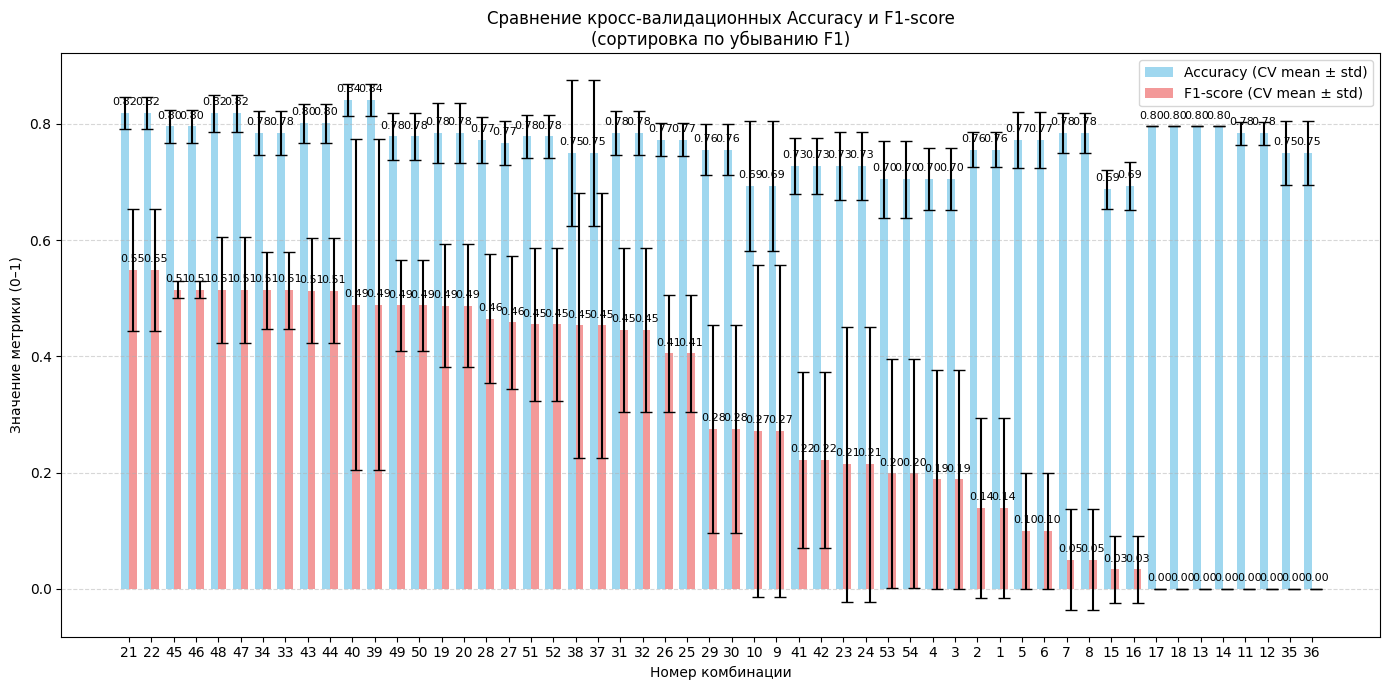

In [9]:
df_res.to_csv('hyperparameter_tuning_results.csv', index=False, encoding='utf-8')

plot_results(df_res, output_path='hyperparameter_tuning_histograms.png')

In [12]:
print_sorted_by_f1(df_res)


=== Результаты гиперпараметрического поиска (сортировка по убыванию F1) ===

 combo_id hidden_layer_sizes activation solver  max_iter  cv_mean_f1  cv_std_f1  cv_mean_accuracy  cv_std_accuracy
       21                100       relu  lbfgs      1000    0.548428   0.104829          0.818182         0.027835
       22                100       relu  lbfgs      5000    0.548428   0.104829          0.818182         0.027835
       45               1000       tanh  lbfgs      1000    0.514912   0.015117          0.795455         0.027835
       46               1000       tanh  lbfgs      5000    0.514912   0.015117          0.795455         0.027835
       48               1000       tanh    sgd      5000    0.513889   0.091604          0.818182         0.032141
       47               1000       tanh    sgd      1000    0.513889   0.091604          0.818182         0.032141
       34                100   logistic  lbfgs      5000    0.513636   0.066135          0.784091         0.037689
  

Номер выборки - 21
Гиперпараметры - hidden_layer_sizes=100, activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.8182 ± 0.0278, F1-score = 0.5484 ± 0.1048


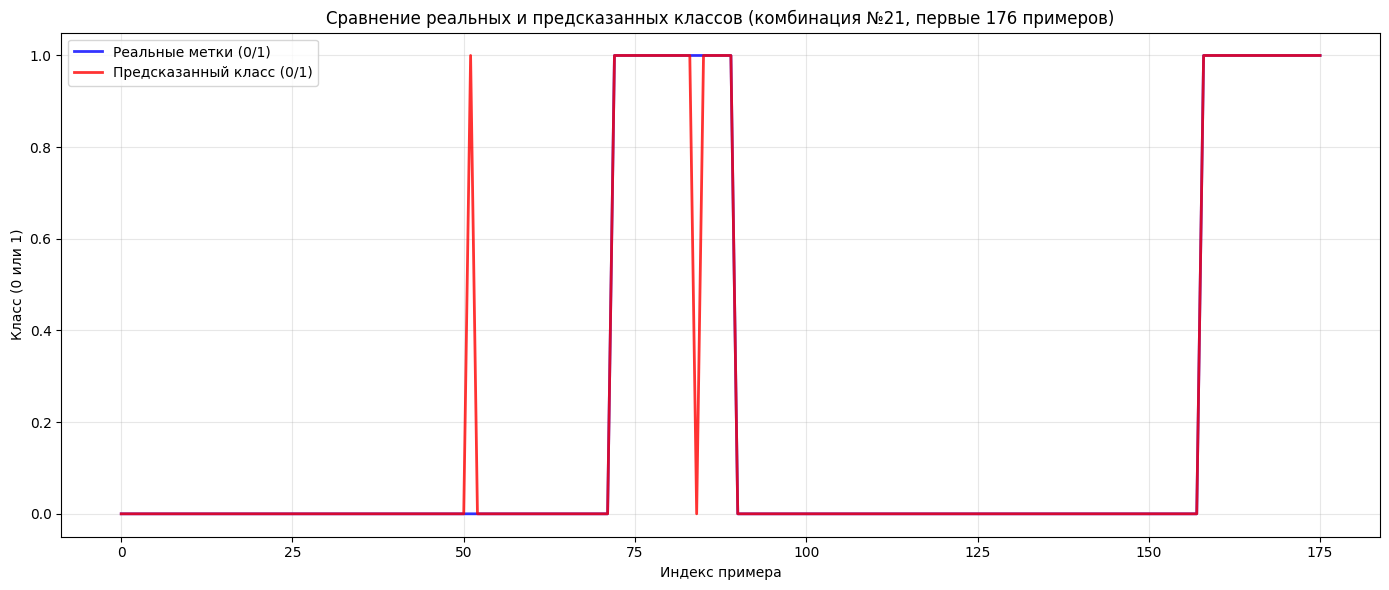

In [21]:
plot_model_by_combo_id(
    21,
    df_res,
    data_x,
    data_y,
    config['base']['random_state'],
    176
)

Номер выборки - 43
Гиперпараметры - hidden_layer_sizes=1000, activation='tanh', solver='adam', max_iter=1000
Accuracy = 0.8011 ± 0.0336, F1-score = 0.5132 ± 0.0909


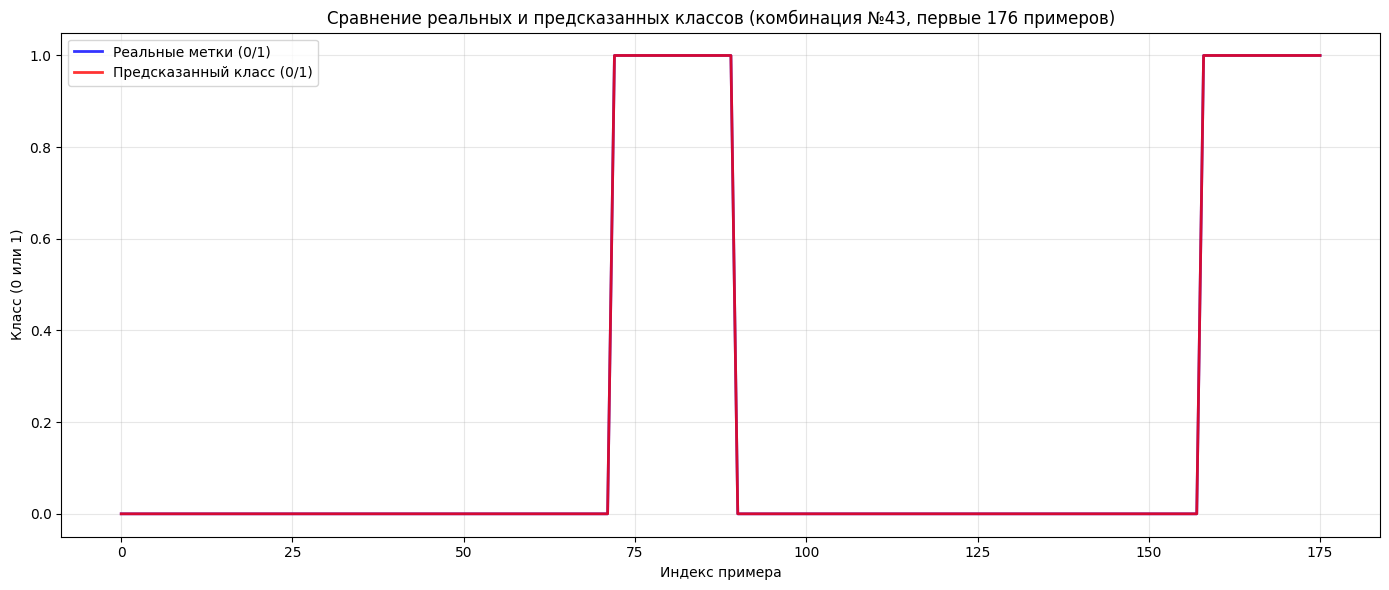

In [22]:
plot_model_by_combo_id(
    43,
    df_res,
    data_x,
    data_y,
    config['base']['random_state'],
    176
)

#### <font color='#F5DEB3'> 1.2 Тестирование с двумя слоями

In [23]:
hidden_opts = [(10, 10), (100, 10), (1000, 10)]
act_opts = ['relu', 'tanh', 'logistic']
solv_opts = ['adam', 'lbfgs', 'sgd']
iter_opts = [1000]

In [24]:
df_res = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.784 (±0.061), F1-score: 0.424 (±0.196)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.812 (±0.019), F1-score: 0.373 (±0.240)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=sgd, max_iter=1000 → Accuracy: 0.767 (±0.037), F1-score: 0.079 (±0.137)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.688 (±0.081), F1-score: 0.029 (±0.051)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


...

Номер набора № 10. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.778 (±0.034), F1-score: 0.432 (±0.021)
Номер набора № 11. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.790 (±0.052), F1-score: 0.384 (±0.248)
Номер набора № 12. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=relu, solver=sgd, max_iter=1000 → Accuracy: 0.619 (±0.137), F1-score: 0.059 (±0.102)
Номер набора № 13. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.784 (±0.041), F1-score: 0.476 (±0.035)
Номер набора № 14. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.807 (±0.025), F1-score: 0.562 (±0.061)
Номер набора № 15. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=tanh, solver=sgd, max_iter=1000 → Accuracy: 0.722 (±0.025), F1-score: 0.102 (±0.111)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 16. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=logistic, solver=adam, max_iter=1000 → Accuracy: 0.778 (±0.019), F1-score: 0.462 (±0.066)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 17. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=logistic, solver=lbfgs, max_iter=1000 → Accuracy: 0.727 (±0.028), F1-score: 0.396 (±0.127)
Номер набора № 18. Гиперпараметры: hidden_layer_sizes=(100, 10), activation=logistic, solver=sgd, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 19. Гиперпараметры: hidden_layer_sizes=(1000, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.818 (±0.043), F1-score: 0.526 (±0.110)
Номер набора № 20. Гиперпараметры: hidden_layer_sizes=(1000, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.790 (±0.019), F1-score: 0.500 (±0.081)
Номер набора № 21. Гиперпараметры: hidden_layer_sizes=(1000, 10), activation=relu, solver=sgd, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 22. Гиперпараметры: hidden_layer_sizes=(1000, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.028), F1-score: 0.494 (±0.074)
Номер набора № 2

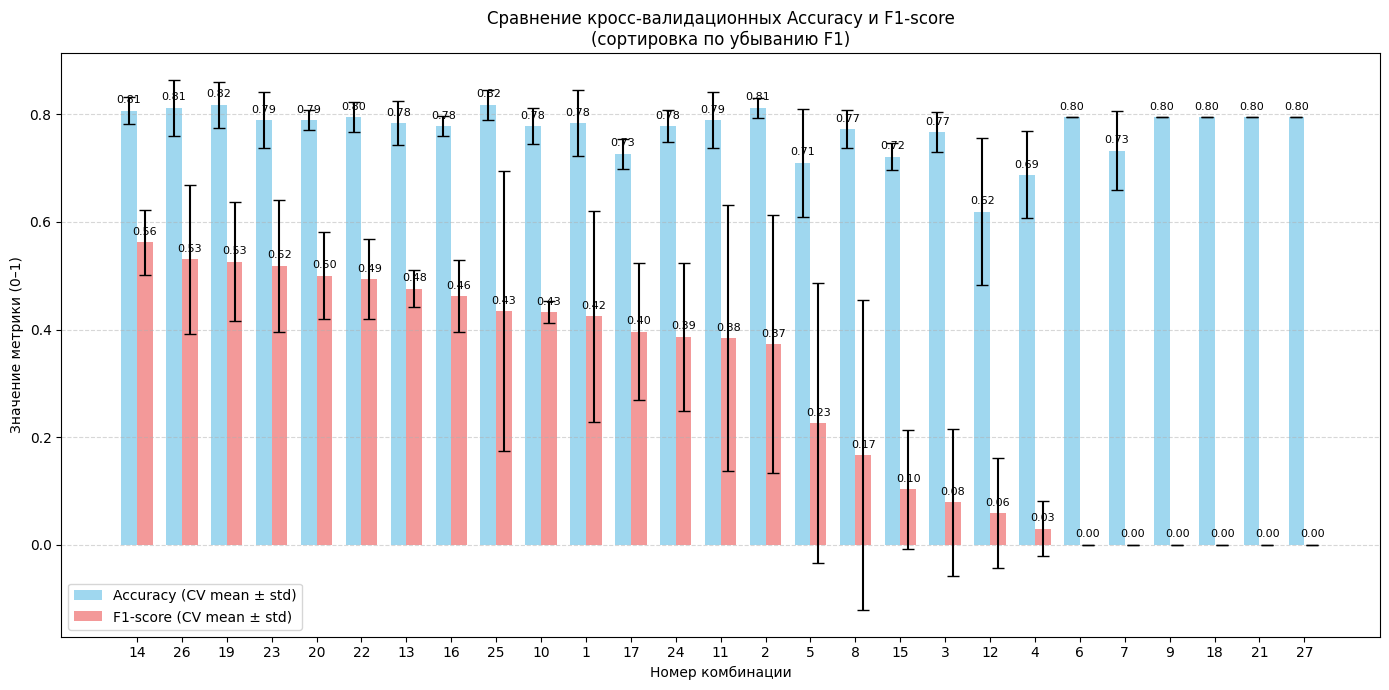

In [25]:
df_res.to_csv('hyperparameter_tuning_results.csv', index=False, encoding='utf-8')

plot_results(df_res, output_path='hyperparameter_tuning_histograms.png')

In [26]:
print_sorted_by_f1(df_res)


=== Результаты гиперпараметрического поиска (сортировка по убыванию F1) ===

 combo_id hidden_layer_sizes activation solver  max_iter  cv_mean_f1  cv_std_f1  cv_mean_accuracy  cv_std_accuracy
       14          (100, 10)       tanh  lbfgs      1000    0.561905   0.061064          0.806818         0.025410
       26         (1000, 10)   logistic  lbfgs      1000    0.530596   0.138377          0.812500         0.051764
       19         (1000, 10)       relu   adam      1000    0.526304   0.110115          0.818182         0.042519
       23         (1000, 10)       tanh  lbfgs      1000    0.518421   0.123067          0.789773         0.051764
       20         (1000, 10)       relu  lbfgs      1000    0.500329   0.081113          0.789773         0.018844
       22         (1000, 10)       tanh   adam      1000    0.493985   0.073964          0.795455         0.027835
       13          (100, 10)       tanh   adam      1000    0.475728   0.034540          0.784091         0.040972
  

Номер выборки - 14
Гиперпараметры - hidden_layer_sizes=(100, 10), activation='tanh', solver='lbfgs', max_iter=1000
Accuracy = 0.8068 ± 0.0254, F1-score = 0.5619 ± 0.0611


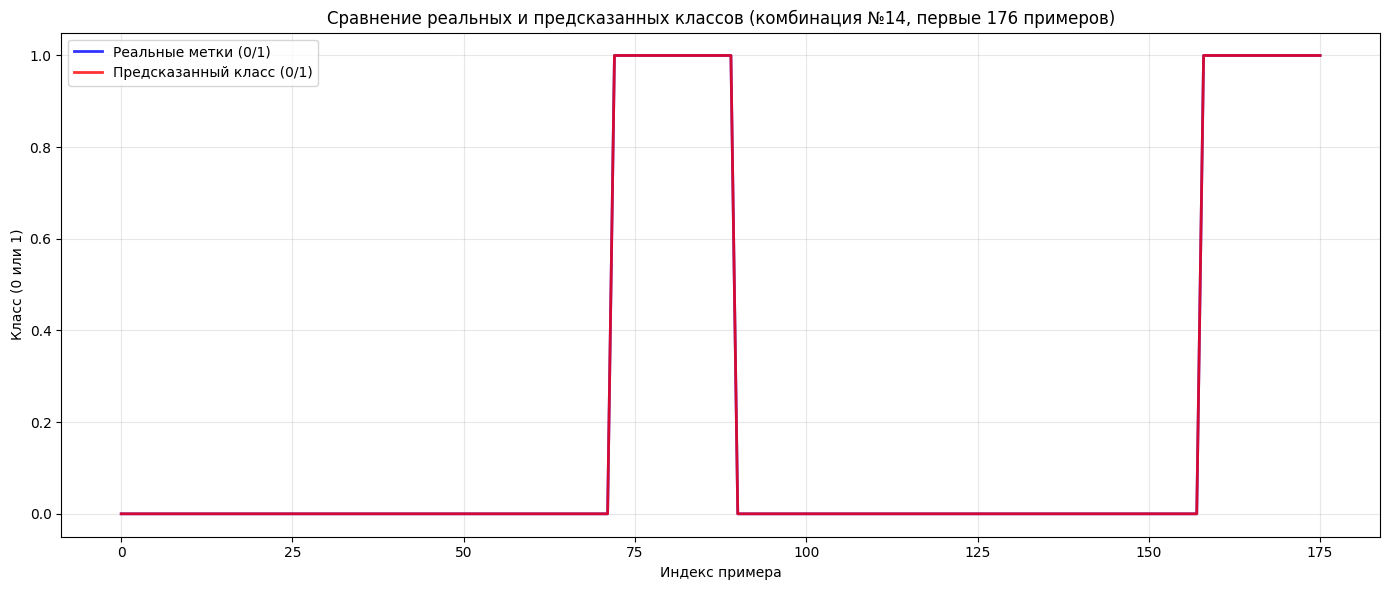

In [27]:
plot_model_by_combo_id(
    14,
    df_res,
    data_x,
    data_y,
    config['base']['random_state'],
    176
)

Номер выборки - 43
Гиперпараметры - hidden_layer_sizes=1000, activation='tanh', solver='adam', max_iter=1000
Accuracy = 0.8011 ± 0.0336, F1-score = 0.5132 ± 0.0909


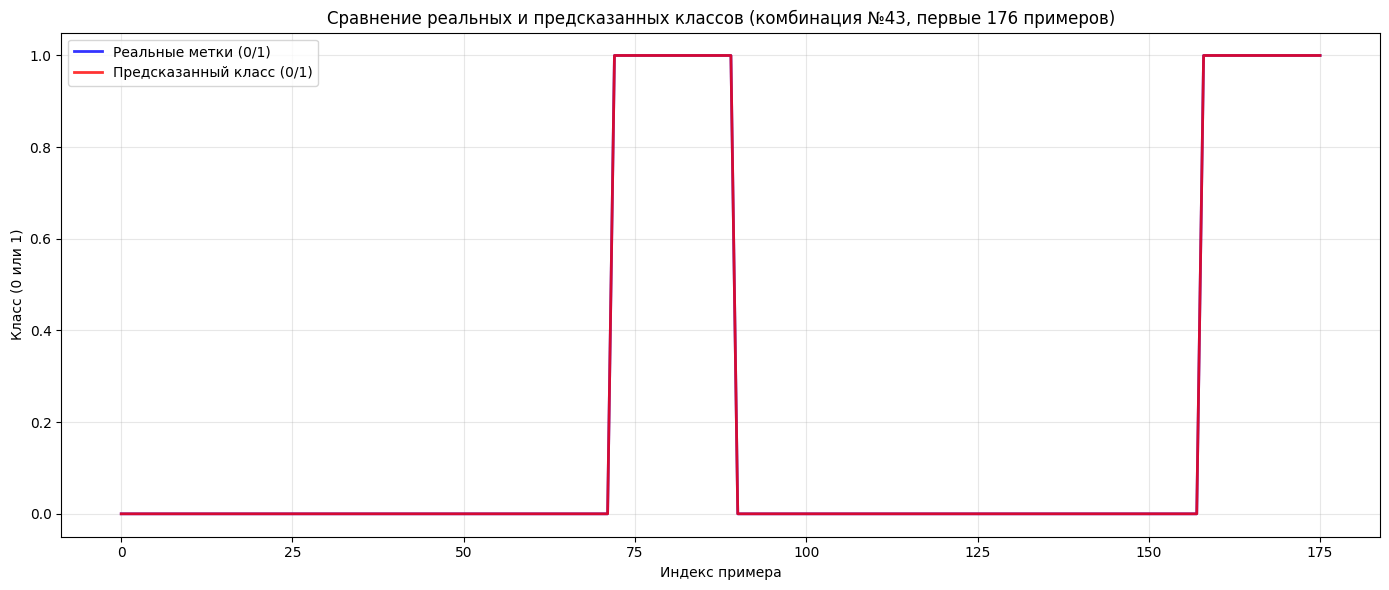

In [ ]:
plot_model_by_combo_id(
    43,
    df_res,
    data_x,
    data_y,
    config['base']['random_state'],
    176
)

#### <font color='#F5DEB3'> 1.2 Тестирование с двумя слоями

### <font color='#F5DEB3'>Задание №4

Зафиксировать **лучший полученный результат** по п.3 – выставить в блокноте результат лучшего найденного результата обучения (график и значения критериев понадобятся для отчёта).

In [ ]:
type_space = config['data']['type_space']
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

data_y = np.where(data_y == type_space, 1, 0)

scaler = MinMaxScaler()
data_x_scaled = scaler.fit_transform(data_x)

In [ ]:
# ------------------- Параметры перебора -------------------
hidden_options = [(3,2), (10,2), (3,3), (10,3), (3,5), (10,5)]
act_options = ['relu', 'tanh', 'logistic']
solv_options = ['adam']
max_iter_options = [5000, 10000]

random_state = config['base']['random_state']
cv_folds = config['MLP']['model_params']['cv_folds']

# ------------------- Сбор результатов -------------------
results = []
combo_id = 0

for hls in hidden_options:
    for act in act_options:
        for solv in solv_options:
            for max_it in max_iter_options:
                combo_id += 1
                mlp = MLPClassifier(
                    hidden_layer_sizes=hls,
                    activation=act,
                    solver=solv,
                    max_iter=max_it,
                    random_state=random_state,
                )
                
                # Кросс-валидация для Accuracy
                scores_acc = cross_val_score(mlp, data_x_scaled, data_y, cv=cv_folds, scoring='accuracy')
                mean_acc = scores_acc.mean()
                std_acc  = scores_acc.std()
                
                # Кросс-валидация для F1-score
                scores_f1 = cross_val_score(mlp, data_x_scaled, data_y, cv=cv_folds, scoring='f1')
                mean_f1 = scores_f1.mean()
                std_f1  = scores_f1.std()
                
                # Сохраняем в список
                results.append({
                    'combo_id': combo_id,
                    'hidden_layer_sizes': str(hls),
                    'activation': act,
                    'solver': solv,
                    'max_iter': max_it,
                    'cv_mean_accuracy': mean_acc,
                    'cv_std_accuracy': std_acc,
                    'cv_mean_f1': mean_f1,
                    'cv_std_f1': std_f1
                })

# ------------------- DataFrame с результатами -------------------
df_results_norm = pd.DataFrame(results)

# Сохранение в файл
df_results_norm.to_csv('hyperparameter_tuning_results_norm.csv', index=False, encoding='utf-8')

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\utils\_response.py", line 207, in _get_response_values
    raise ValueError(
ValueError: pos_label=1 is not a valid label: It should be one of [0]

  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWa

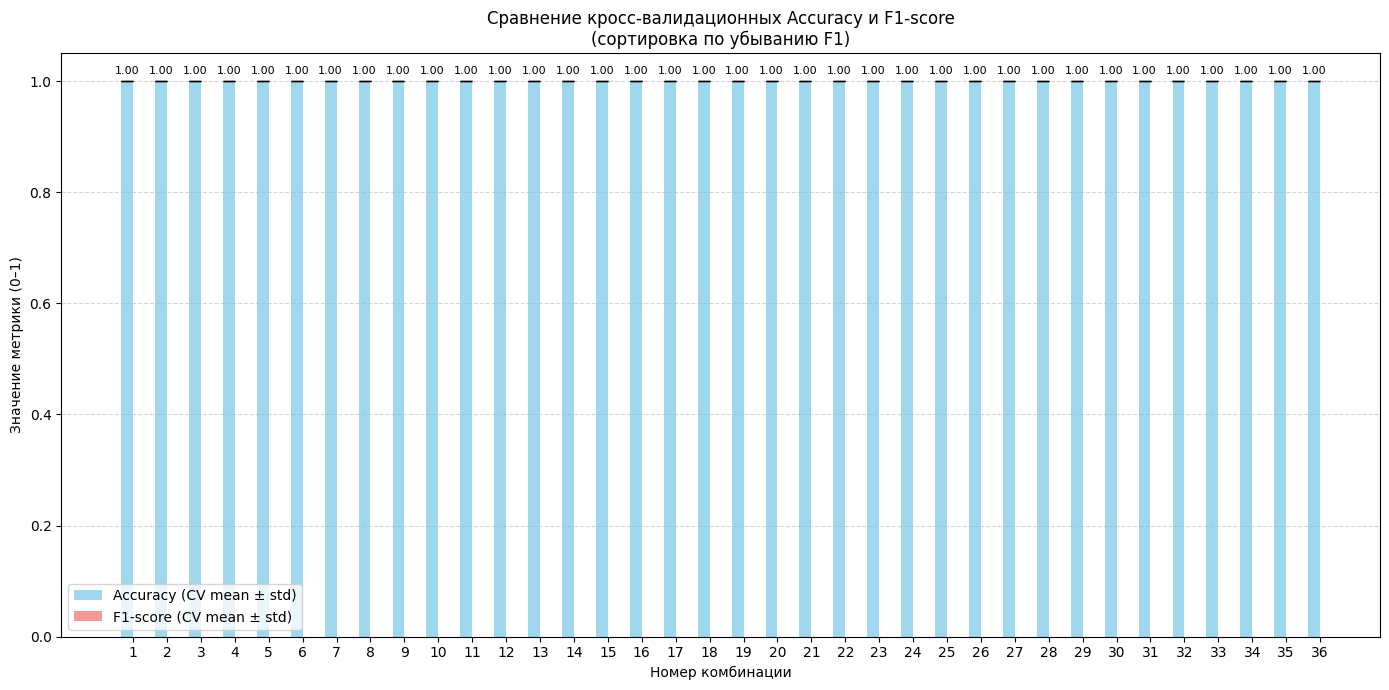

In [ ]:
df_results_norm['cv_mean_accuracy_frac'] = df_results_norm['cv_mean_accuracy']  # уже в долях
df_results_norm['cv_std_accuracy_frac'] = df_results_norm['cv_std_accuracy']

# Сортируем по убыванию F1 (наиболее важная метрика)
df_sorted = df_results_norm.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

# Позиции для столбцов
x = np.arange(len(df_sorted))
width = 0.35  # ширина одного столбца

fig, ax = plt.subplots(figsize=(14, 7))

# Столбцы для Accuracy
bars_acc = ax.bar(x - width/2, df_sorted['cv_mean_accuracy_frac'], width,
                  yerr=df_sorted['cv_std_accuracy_frac'], capsize=4,
                  label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8)

# Столбцы для F1-score
bars_f1 = ax.bar(x + width/2, df_sorted['cv_mean_f1'], width,
                 yerr=df_sorted['cv_std_f1'], capsize=4,
                 label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8)

# Подписи оси X: номера комбинаций (можно добавить краткие гиперпараметры, но это перегрузит)
ax.set_xlabel('Номер комбинации')
ax.set_ylabel('Значение метрики (0–1)')
ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n(сортировка по убыванию F1)')
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['combo_id'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим числовые значения поверх столбцов (опционально)
for bar in bars_acc:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_f1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('hyperparameter_tuning_histograms_norm.png', dpi=600)
plt.show()

Номер выборки - 7
Гиперпараметры - hidden_layer_sizes=(10, 2), activation='relu', solver='adam', max_iter=5000
Accuracy = 1.0000 ± 0.0000, F1-score = nan ± nan


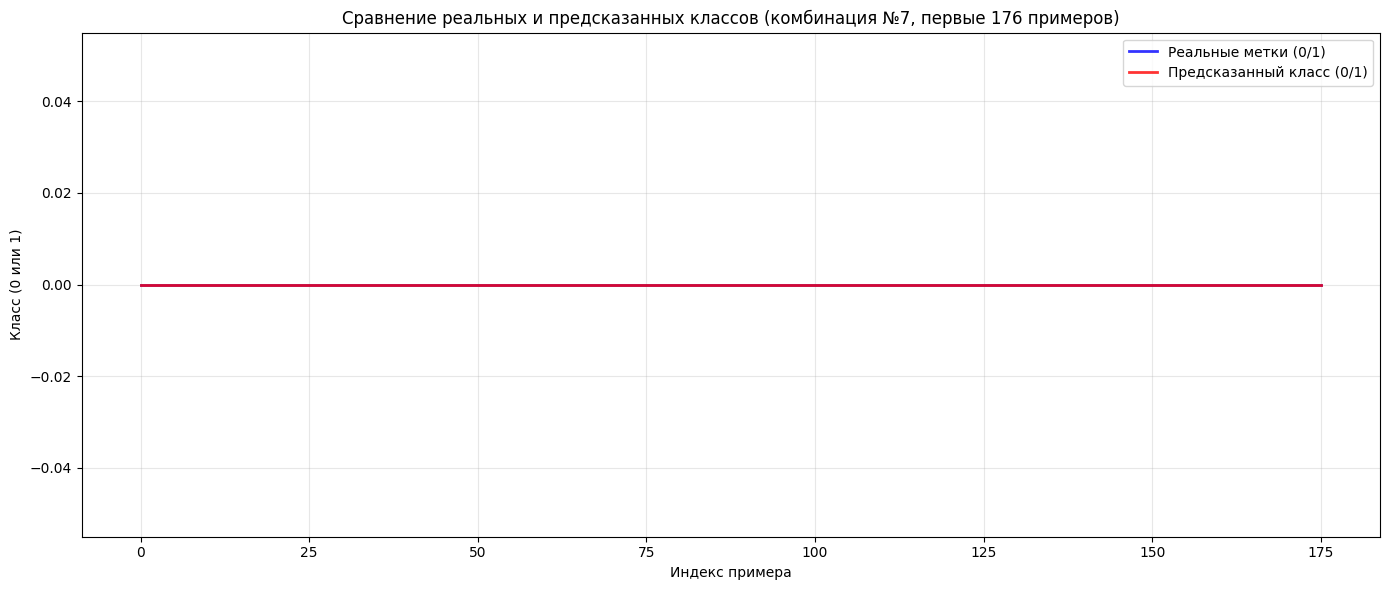

In [ ]:
number_param = 7
plot_model_by_combo_id(number_param, df_results_norm, data_x_scaled, data_y, random_state)

In [ ]:
smote = SMOTE(random_state=42)
adasyn = ADASYN(random_state=42)

X_smote, Y_smote = smote.fit_resample(data_x_scaled, data_y)
X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled, data_y)


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [ ]:
best_params = {
    'hidden_layer_sizes': (10, 2),
    'activation': 'relu',
    'solver': 'adam',
    'max_iter': 5000,
    'random_state': 42,
}

In [ ]:
def plot_predictions(model, X, y_true, n_show=1000, title_suffix='', save_path='predictions_plot.png'):
    """
    Строит график сравнения реальных и предсказанных классов для обученной модели.

    Параметры:
    ----------
    model : обученный классификатор с методом predict
    X : np.ndarray, матрица признаков
    y_true : np.ndarray, вектор истинных меток (0/1)
    n_show : int, количество отображаемых примеров (первые n_show)
    title_suffix : str, дополнительный текст в заголовке
    save_path : str, путь для сохранения графика
    """
    y_pred = model.predict(X)
    
    n = min(n_show, len(y_true))
    indices = np.arange(n)
    
    plt.figure(figsize=(14, 6))
    plt.plot(indices, y_true[:n], label='Реальные метки',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n], label='Предсказанные классы',
             color='red', linewidth=2, alpha=0.8)
    
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0/1)')
    title = 'Сравнение реальных и предсказанных классов'
    if title_suffix:
        title += f' ({title_suffix})'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.show()

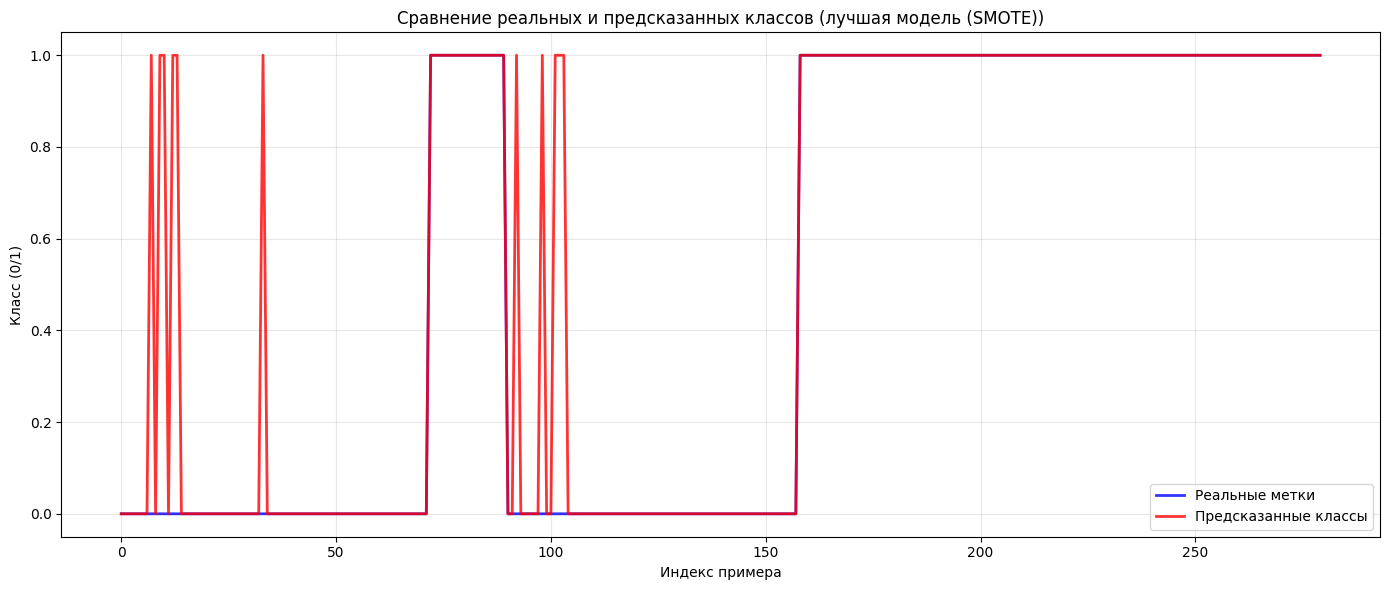

In [ ]:
mlp = MLPClassifier(**best_params)
                
# Кросс-валидация для Accuracy
scores_acc = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='accuracy')
mean_acc = scores_acc.mean()
std_acc  = scores_acc.std()

# Кросс-валидация для F1-score
scores_f1 = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
mean_f1 = scores_f1.mean()
std_f1  = scores_f1.std()

# Сохраняем в список
results.append({
    'hidden_layer_sizes': str(hls),
    'activation': act,
    'solver': solv,
    'max_iter': max_it,
    'cv_mean_accuracy': mean_acc,
    'cv_std_accuracy': std_acc,
    'cv_mean_f1': mean_f1,
    'cv_std_f1': std_f1
})

df_results_smote = pd.DataFrame(results)

mlp.fit(X_smote, Y_smote)

plot_predictions(mlp, X_smote, Y_smote, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions.png')


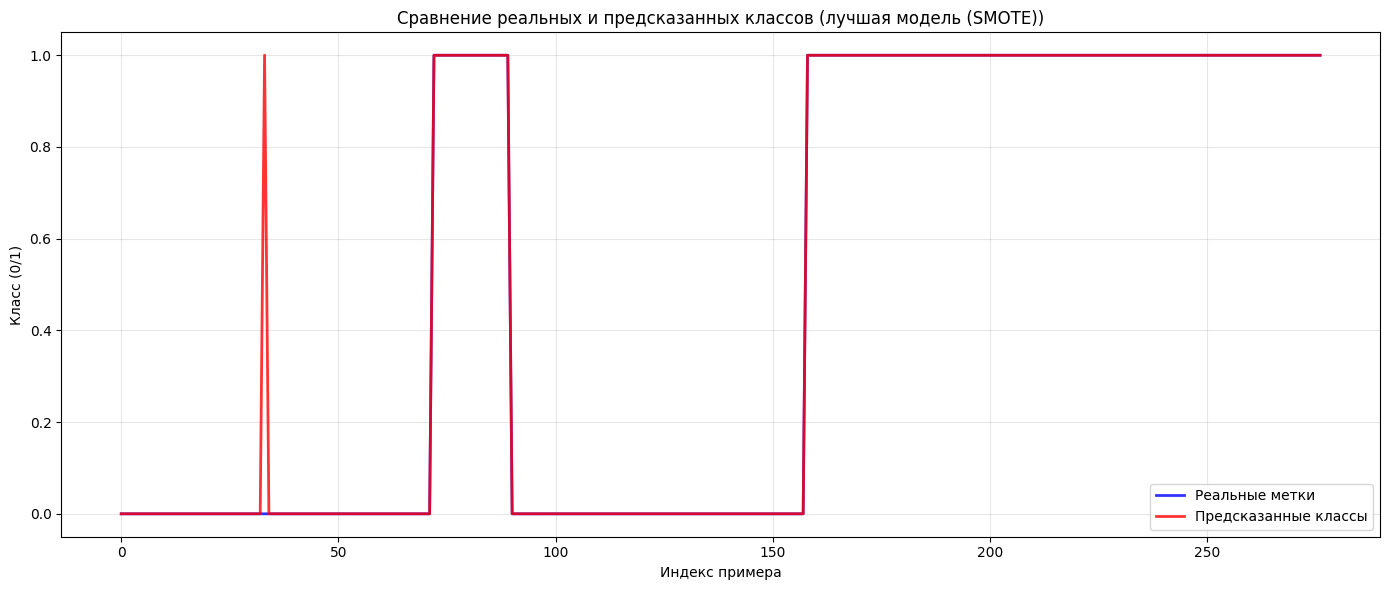

In [ ]:
mlp = MLPClassifier(**best_params)
                
# Кросс-валидация для Accuracy
scores_acc = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='accuracy')
mean_acc = scores_acc.mean()
std_acc  = scores_acc.std()

# Кросс-валидация для F1-score
scores_f1 = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='f1')
mean_f1 = scores_f1.mean()
std_f1  = scores_f1.std()

# Сохраняем в список
results.append({
    'hidden_layer_sizes': str(hls),
    'activation': act,
    'solver': solv,
    'max_iter': max_it,
    'cv_mean_accuracy': mean_acc,
    'cv_std_accuracy': std_acc,
    'cv_mean_f1': mean_f1,
    'cv_std_f1': std_f1
})

df_results_adasyn = pd.DataFrame(results)

mlp.fit(X_adasyn, Y_adasyn)

plot_predictions(mlp, X_adasyn, Y_adasyn, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions.png')


In [ ]:
V1_C = pd.read_excel(config['data']['dataset_test_xlsx'])
display(V1_C.head(), V1_C.info(), V1_C.describe())

dt = 0.01
# Метод Эйлера
V1_alpha = np.zeros(len(V1_C))
for i in range(1, len(V1_C)):
    V1_alpha[i] = V1_alpha[i-1] + V1_C['gz'].values[i-1] * dt

V2_C, V3_C = compute_V2_V3(V1_C, V1_alpha, config)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
dtypes: float64(12), int64(4)
memory usage: 7.4 KB


,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
0,1.143286,0.016591,1.073907,0.343529,-0.032941,0.185294,0.018899,-0.003246,0.004323,-254.117647,0.000000,257.294118,-5081,-2,5062,1
1,0.499246,1.135747,0.481146,0.654118,0.263529,-1.826471,0.009004,-0.015884,-0.007669,162.000000,-308.117647,154.058824,2952,-5933,2991,1
2,0.351433,0.874811,0.942685,0.845882,0.114118,-3.032941,0.016070,-0.034309,-0.008215,-111.176471,-327.176471,462.176471,-2065,-6018,8444,1
3,0.333333,0.459566,0.258382,0.533077,-1.130769,16.233077,-0.008263,0.007343,0.021297,157.846154,162.000000,170.307692,3503,3338,3533,1
4,0.347008,0.353846,0.336752,0.093333,-1.026667,34.422667,-0.003776,-0.000049,0.003906,360.000000,352.800000,349.200000,5917,5931,5939,1


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000


In [ ]:
V3_C

,Tx,Ty,Tφ,Tz
0,9.226292,-1.831357,-14.650860,-8.012189
1,16.569436,11.467625,-16.357236,35.270291
2,17.712676,17.170432,-26.885145,32.087918
3,-6.002289,-0.391387,149.198143,46.323688
4,51.045007,-2.197545,327.523142,99.525247
5,2.662126,-8.673908,590.768634,184.140547
6,20.310336,31.740600,-16.174057,-10.146226
7,42.703817,62.563897,-17.971224,1.060801
8,91.736395,51.718592,-22.631657,-17.305534
9,-2.690158,-4.094441,233.528809,86.389274


In [ ]:
V13_C = pd.concat([V1_C, V3_C], axis=1)
display(V13_C)

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
0,1.143286,0.016591,1.073907,0.343529,-0.032941,0.185294,0.018899,-0.003246,0.004323,-254.117647,0.000000,257.294118,-5081,-2,5062,1,9.226292,-1.831357,-14.650860,-8.012189
1,0.499246,1.135747,0.481146,0.654118,0.263529,-1.826471,0.009004,-0.015884,-0.007669,162.000000,-308.117647,154.058824,2952,-5933,2991,1,16.569436,11.467625,-16.357236,35.270291
2,0.351433,0.874811,0.942685,0.845882,0.114118,-3.032941,0.016070,-0.034309,-0.008215,-111.176471,-327.176471,462.176471,-2065,-6018,8444,1,17.712676,17.170432,-26.885145,32.087918
3,0.333333,0.459566,0.258382,0.533077,-1.130769,16.233077,-0.008263,0.007343,0.021297,157.846154,162.000000,170.307692,3503,3338,3533,1,-6.002289,-0.391387,149.198143,46.323688
4,0.347008,0.353846,0.336752,0.093333,-1.026667,34.422667,-0.003776,-0.000049,0.003906,360.000000,352.800000,349.200000,5917,5931,5939,1,51.045007,-2.197545,327.523142,99.525247
5,0.350961,0.451923,0.437500,-0.688750,-5.436250,76.135000,0.009110,0.022644,0.087982,759.375000,762.750000,767.812500,13176,13081,13128,1,2.662126,-8.673908,590.768634,184.140547
6,0.505983,0.003419,0.288889,0.724000,0.322000,0.722667,-0.001660,0.006966,0.002360,-291.600000,1.800000,300.600000,-4703,6,4877,2,20.310336,31.740600,-16.174057,-10.146226
7,0.224359,0.278846,0.174679,0.560625,0.382500,0.042500,-0.009125,-0.019577,0.008163,168.750000,-356.062500,180.562500,3007,-6222,3059,2,42.703817,62.563897,-17.971224,1.060801
8,0.225641,0.283760,0.280342,0.378667,0.157333,1.321333,0.008350,0.009814,0.001465,-113.400000,-354.600000,484.200000,-2035,-6223,8546,2,91.736395,51.718592,-22.631657,-17.305534
9,0.282051,0.331624,0.099145,0.541333,-0.878667,20.526667,0.002083,-0.017399,-0.005501,167.400000,165.600000,187.200000,2732,2726,2953,2,-2.690158,-4.094441,233.528809,86.389274


In [ ]:
feature_cols_C = [col for col in V13_C.columns if col not in target_col]

dataC_x = np.array(V13_C.drop(target_col, axis=1))
dataC_y = np.array(V13_C[target_col]).ravel()

dataC_y = np.where(dataC_y == type_space, 1, 0)

scaler = MinMaxScaler()
dataC_x_scaled = scaler.fit_transform(dataC_x)

In [ ]:
X_C_adasyn, Y_C_adasyn = adasyn.fit_resample(dataC_x_scaled, dataC_y)

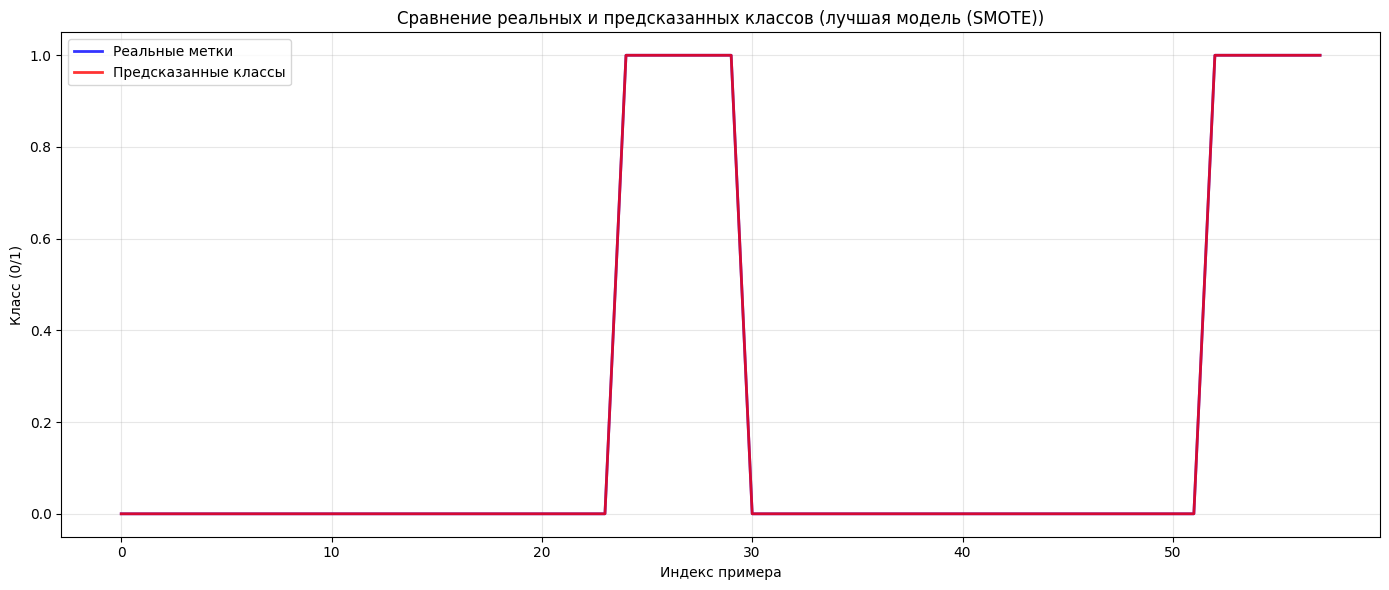

In [ ]:
mlp.fit(dataC_x_scaled, dataC_y)

plot_predictions(mlp, dataC_x_scaled, dataC_y, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions_C.png')

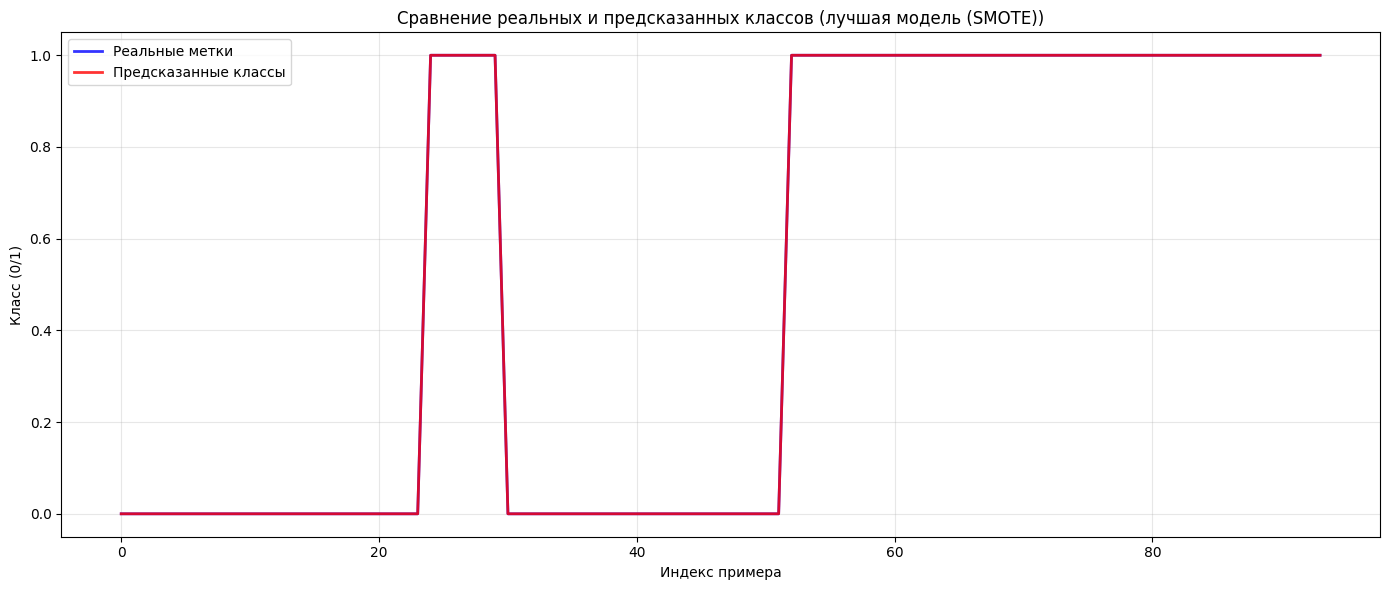

In [ ]:
mlp.fit(X_C_adasyn, Y_C_adasyn)

plot_predictions(mlp, X_C_adasyn, Y_C_adasyn, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions_C.png')